# LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# EDA


In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df_cleaned = df.copy()

In [4]:
df_cleaned.shape

(918, 12)

In [5]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [6]:
df_cleaned.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
df_cleaned.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df_cleaned.duplicated().sum()

np.int64(0)

In [9]:
df_cleaned.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
df_cleaned.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

Fixing numeric columns

In [11]:
int_cols = ['Age', 'MaxHR', 'Cholesterol','RestingBP', 'Oldpeak']

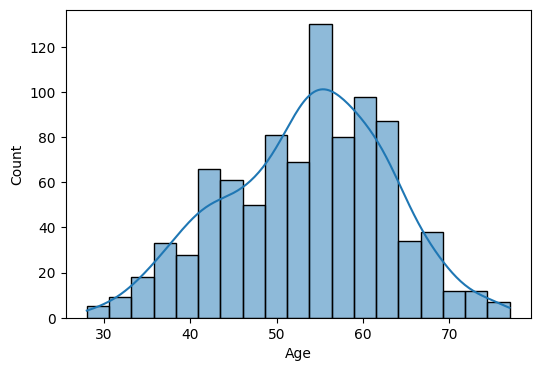

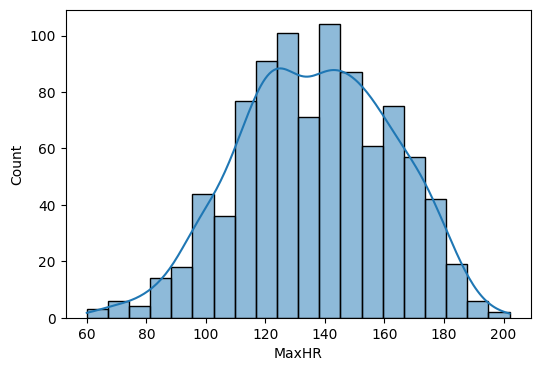

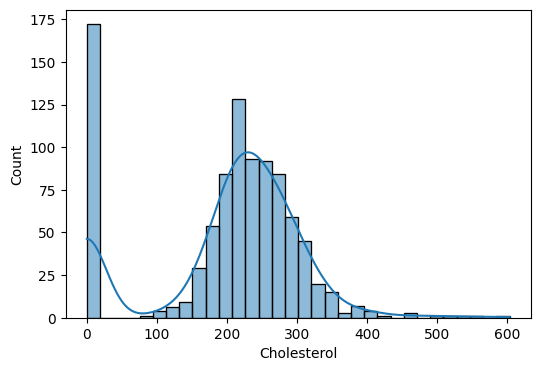

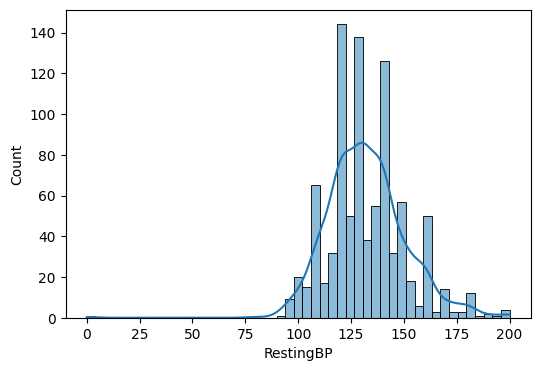

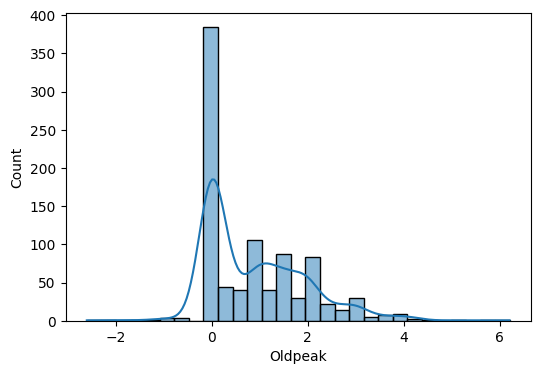

In [12]:
for col in int_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data = df_cleaned, x = col, kde= True)

In [13]:
df_cleaned = df_cleaned[df_cleaned['RestingBP'] != 0]

In [14]:
df_cleaned['Cholesterol'] = df_cleaned['Cholesterol'].replace(0, df_cleaned['Cholesterol'].median())

In [15]:
df_cleaned.loc[df_cleaned['Oldpeak'] < 0, 'Oldpeak'] = df_cleaned['Oldpeak'].median()
df_cleaned['Oldpeak'] = np.log1p(df_cleaned['Oldpeak']).round(2)

In [16]:
df_cleaned['Cholesterol'].value_counts()

Cholesterol
223    181
254     11
220     10
216      9
230      9
      ... 
347      1
365      1
412      1
491      1
131      1
Name: count, Length: 221, dtype: int64

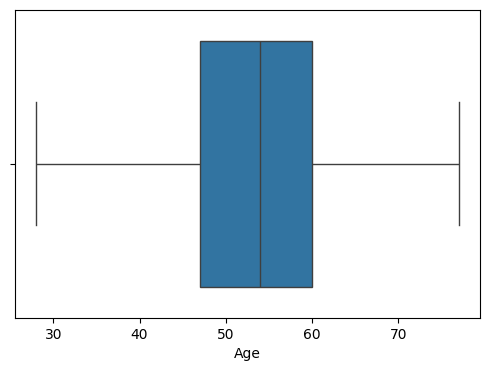

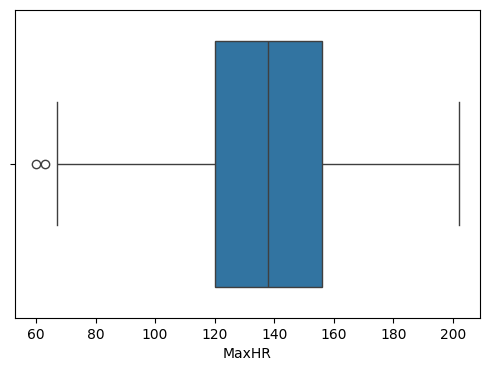

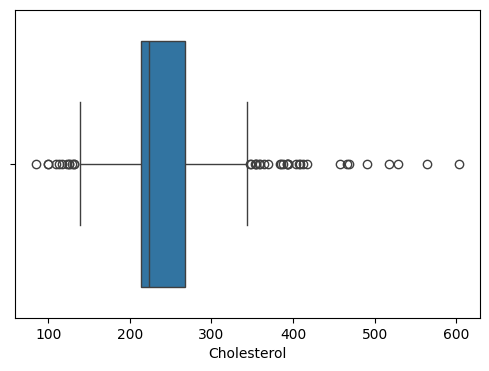

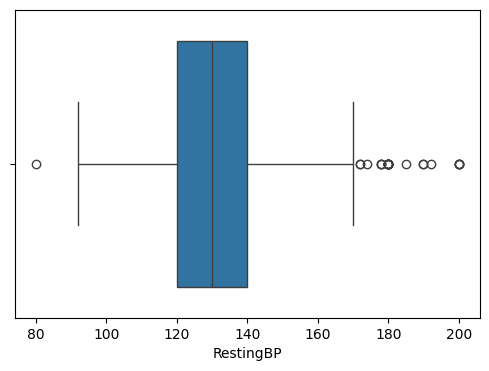

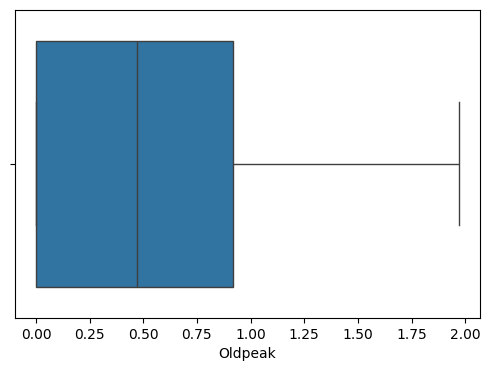

In [17]:
for col in int_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data = df_cleaned, x = col)

Fixing categorical columns

In [18]:
str_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

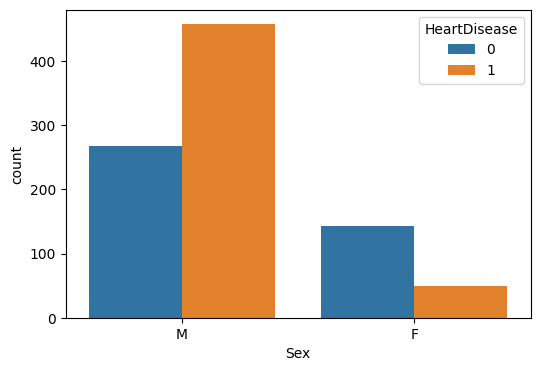

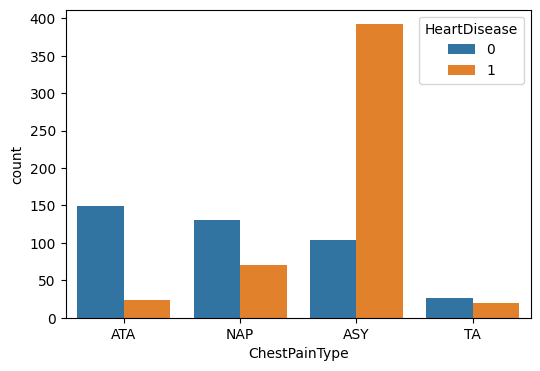

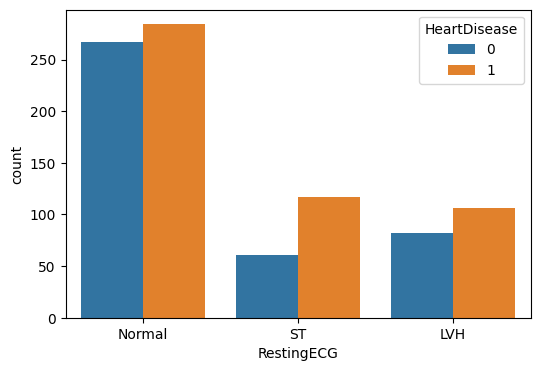

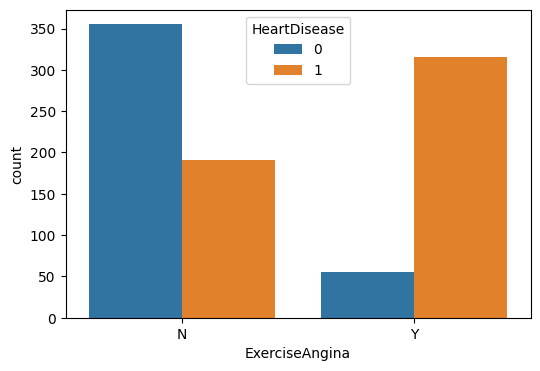

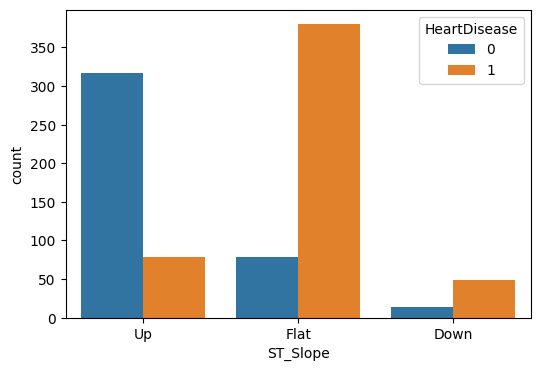

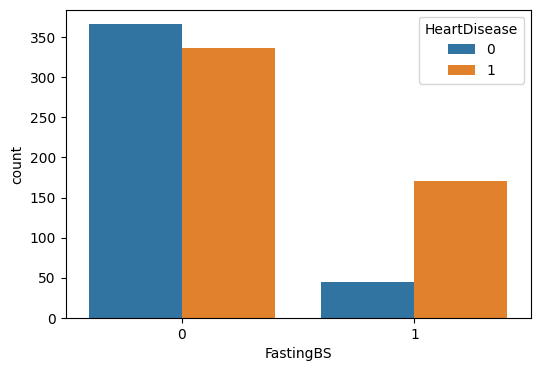

In [19]:
for col in str_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data = df_cleaned, x = col, hue = 'HeartDisease')

<Axes: >

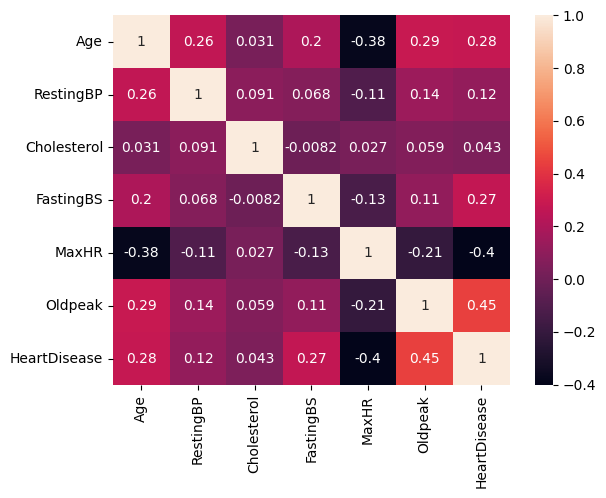

In [20]:
sns.heatmap(df_cleaned.corr(numeric_only=True), annot = True)

In [21]:
df_cleaned

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.00,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,0.69,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.00,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,0.92,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.00,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,0.79,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,1.48,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,0.79,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.00,Flat,1


In [22]:
df_cleaned = pd.get_dummies(data = df_cleaned, columns = str_cols, drop_first=True)

In [23]:
df_cleaned.rename({
    'Sex_M': 'isMale',
    'ExerciseAngina_Y': 'isExerciseAngina',
    'FastingBS_1': 'isFastingBS'
}, axis= 1, inplace=True)

In [24]:
cols_to_convert = ['isMale', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'isExerciseAngina', 'ST_Slope_Flat', 'ST_Slope_Up', 'isFastingBS']

df_cleaned[cols_to_convert] = df_cleaned[cols_to_convert].astype(int)

In [25]:
df_cleaned.head()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,isMale,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,isExerciseAngina,ST_Slope_Flat,ST_Slope_Up,isFastingBS
0,40,140,289,172,0.00,0,1,1,0,0,1,0,0,0,1,0
1,49,160,180,156,0.69,1,0,0,1,0,1,0,0,1,0,0
2,37,130,283,98,0.00,0,1,1,0,0,0,1,0,0,1,0
3,48,138,214,108,0.92,1,0,0,0,0,1,0,1,1,0,0
4,54,150,195,122,0.00,0,1,0,1,0,1,0,0,0,1,0


In [26]:
features_corr_with_HeartDisease = pd.DataFrame(df_cleaned.corr()['HeartDisease']).reset_index().sort_values(by = 'HeartDisease', ascending=False)
features_corr_with_HeartDisease

,index,HeartDisease
5,HeartDisease,1.000000
13,ST_Slope_Flat,0.553700
12,isExerciseAngina,0.495490
4,Oldpeak,0.445190
6,isMale,0.305118
0,Age,0.282012
15,isFastingBS,0.267994
1,RestingBP,0.117990
11,RestingECG_ST,0.103067
2,Cholesterol,0.043329


In [27]:
cat_features = ['isMale', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'isExerciseAngina', 'ST_Slope_Flat', 'ST_Slope_Up', 'isFastingBS']

In [28]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_result = {}
for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['HeartDisease'])
    chi2_stats, p_val, _, _ = chi2_contingency(contingency)
   
    if p_val < alpha:
        decision = 'Reject Null (Keep Feature)'
    else:
        decision = 'Accept Null (Drop Feature)'

    chi2_result[col] = {
        'chi2_stats': chi2_stats,
        'p_value': p_val,
        'decision': decision
    }
chi2_df = pd.DataFrame(chi2_result).T.sort_values(by = 'p_value')

In [29]:
chi2_df

,chi2_stats,p_value,decision
ST_Slope_Up,352.071774,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,278.914655,0.0,Reject Null (Keep Feature)
isExerciseAngina,223.107207,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,145.896978,0.0,Reject Null (Keep Feature)
isMale,83.871151,0.0,Reject Null (Keep Feature)
isFastingBS,64.591342,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,41.472454,0.0,Reject Null (Keep Feature)
RestingECG_ST,9.223969,0.002389,Reject Null (Keep Feature)
RestingECG_Normal,7.462806,0.006299,Reject Null (Keep Feature)
ChestPainType_TA,2.252946,0.13336,Accept Null (Drop Feature)


In [30]:
final_df = df_cleaned[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ST_Slope_Up', 'ST_Slope_Flat', 'isExerciseAngina', 'ChestPainType_ATA', 'isMale', 'isFastingBS', 'ChestPainType_NAP', 'RestingECG_ST', 'RestingECG_Normal', 'HeartDisease']]
final_df

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,ST_Slope_Up,ST_Slope_Flat,isExerciseAngina,ChestPainType_ATA,isMale,isFastingBS,ChestPainType_NAP,RestingECG_ST,RestingECG_Normal,HeartDisease
0,40,140,289,172,0.00,1,0,0,1,1,0,0,0,1,0
1,49,160,180,156,0.69,0,1,0,0,0,0,1,0,1,1
2,37,130,283,98,0.00,1,0,0,1,1,0,0,1,0,0
3,48,138,214,108,0.92,0,1,1,0,0,0,0,0,1,1
4,54,150,195,122,0.00,1,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,132,0.79,0,1,0,0,1,0,0,0,1,1
914,68,144,193,141,1.48,0,1,0,0,1,1,0,0,1,1
915,57,130,131,115,0.79,0,1,1,0,1,0,0,0,1,1
916,57,130,236,174,0.00,0,1,0,1,0,0,0,0,0,1


# MODELS

## DATA SPLIT & SCALING

In [31]:
x  = final_df.drop('HeartDisease', axis = 1)
y = final_df['HeartDisease']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


## BASE MODELS

In [32]:
base_models_dic = {'lr_base_model': LogisticRegression(), 'knn_base_model': KNeighborsClassifier(), 'svc_base_model': SVC(), 'nv_base_model': GaussianNB(), 'dt_base_model': DecisionTreeClassifier(random_state=42), 'rf_base_model': RandomForestClassifier(random_state= 42, n_estimators=100)}
base_models_accuracy = {}
base_models_score = {}

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
for name, base_model in base_models_dic.items():
    if name in ['lr_base_model', 'knn_base_model', 'svc_base_model']:
        base_model.fit(x_train_scaled, y_train)
        y_predict = base_model.predict(x_test_scaled)
        base_models_accuracy[name] = accuracy_score(y_test, y_predict)
        base_models_score[name] = base_model.score(x_train_scaled, y_train)
    else:
        base_model.fit(x_train, y_train)
        y_predict = base_model.predict(x_test)
        base_models_accuracy[name] = accuracy_score(y_test, y_predict)
        base_models_score[name] = base_model.score(x_train, y_train)

In [34]:
base_models_df = pd.DataFrame({
    'Accuracy': base_models_accuracy,
    'Score': base_models_score
}).sort_values(by= 'Accuracy', ascending=False)
base_models_df

,Accuracy,Score
rf_base_model,0.885870,1.000000
knn_base_model,0.869565,0.889495
svc_base_model,0.869565,0.903138
lr_base_model,0.864130,0.863574
nv_base_model,0.831522,0.856753
dt_base_model,0.788043,1.000000


## HYPERPARAMETER TUNING ON RF AND DT

In [35]:
tuned_models_dic = {}
tuned_models_accuracy = {}
tuned_models_score = {}

classifier = RandomizedSearchCV(
    estimator = RandomForestClassifier(),
    n_iter = 100,
    param_distributions= {'n_estimators': [100, 200], 'max_depth': [6, 10, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'max_features': ['sqrt']},
    cv = 5,
    random_state = 42
)
classifier.fit(x_train, y_train)
tuned_models_dic['rf_tuned_model'] = classifier.best_estimator_
y_predict = tuned_models_dic['rf_tuned_model'].predict(x_test)
tuned_models_accuracy['rf_tuned_model'] = accuracy_score(y_test, y_predict)
tuned_models_score['rf_tuned_model'] = tuned_models_dic['rf_tuned_model'].score(x_train, y_train)

In [36]:
classifier = RandomizedSearchCV(
    estimator = DecisionTreeClassifier(),
    n_iter = 100,
    param_distributions= {'max_depth': [3, 4, 5, 6, 8, 10], 'min_samples_split': [2, 5, 10, 15], 'min_samples_leaf': [1, 2, 4, 6], 'criterion': ['gini', 'entropy']},
    cv = 5,
    random_state=42
)
classifier.fit(x_train, y_train)
tuned_models_dic['dt_tuned_model'] = classifier.best_estimator_
y_predict = tuned_models_dic['dt_tuned_model'].predict(x_test)
tuned_models_accuracy['dt_tuned_model'] = accuracy_score(y_test, y_predict)
tuned_models_score['dt_tuned_model'] = tuned_models_dic['dt_tuned_model'].score(x_train, y_train)

In [37]:
tuned_models_df = pd.DataFrame({
    'Accuracy': tuned_models_accuracy,
    'Score': tuned_models_score
})

merging base and tuned models df to decide next step

In [38]:
base_and_tuned_models_df = pd.concat([base_models_df, tuned_models_df]).sort_values(by = 'Accuracy', ascending= False)

In [39]:
base_and_tuned_models_df

,Accuracy,Score
rf_base_model,0.885870,1.000000
rf_tuned_model,0.880435,0.954980
knn_base_model,0.869565,0.889495
svc_base_model,0.869565,0.903138
lr_base_model,0.864130,0.863574
nv_base_model,0.831522,0.856753
dt_tuned_model,0.809783,0.848568
dt_base_model,0.788043,1.000000


## ENSEMBLE

### bagging dt model

In [40]:
tuned_models_dic

{'rf_tuned_model': RandomForestClassifier(min_samples_leaf=2, n_estimators=200),
 'dt_tuned_model': DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=6)}

In [41]:
bagged_models_dic = {}
bagged_models_accuracy = {}
bagged_models_score = {}

bagged_models_dic['dt_bagged_model'] = BaggingClassifier(estimator = DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=6, min_samples_split=15, random_state = 42), n_estimators = 50)

bagged_models_dic['dt_bagged_model'].fit(x_train, y_train)
y_predict = bagged_models_dic['dt_bagged_model'].predict(x_test)
bagged_models_accuracy['dt_bagged_model'] = accuracy_score(y_predict, y_test)
bagged_models_score['dt_bagged_model'] = bagged_models_dic['dt_bagged_model'].score(x_train, y_train)

In [42]:
bagged_models_df = pd.DataFrame({
    'Accuracy': bagged_models_accuracy,
    'Score': bagged_models_score
})

merging bagged, base and tuned models df to decide next step

In [43]:
base_tuned_and_bagged_models_df = pd.concat([base_and_tuned_models_df, bagged_models_df]).sort_values(by = 'Accuracy', ascending= False)

In [44]:
base_tuned_and_bagged_models_df

,Accuracy,Score
rf_base_model,0.885870,1.000000
rf_tuned_model,0.880435,0.954980
knn_base_model,0.869565,0.889495
svc_base_model,0.869565,0.903138
lr_base_model,0.864130,0.863574
nv_base_model,0.831522,0.856753
dt_bagged_model,0.831522,0.873124
dt_tuned_model,0.809783,0.848568
dt_base_model,0.788043,1.000000


### XGBOOST

In [45]:
xgboost_models_dic = {}
xgboost_models_accuracy = {}
xgboost_models_score = {}

In [46]:
xgboost_models_dic['xgboost_model'] = XGBClassifier(n_estimators = 100, max_depth = 10, learning_rate = 0.1, subsample = 0.8, colsample_bytree = 0.8)
xgboost_models_dic['xgboost_model'].fit(x_train, y_train)
y_predict = xgboost_models_dic['xgboost_model'].predict(x_test)
xgboost_models_accuracy['xgboost_model'] = accuracy_score(y_test, y_predict)
xgboost_models_score['xgboost_model'] = xgboost_models_dic['xgboost_model'].score(x_train, y_train)

In [47]:
xgboost_df = pd.DataFrame({
    'Accuracy': xgboost_models_accuracy,
    'Score': xgboost_models_score
})

merging bagged, base, tuned and boost models df

In [48]:
base_tuned_bagged_and_boost_models_df = pd.concat([base_tuned_and_bagged_models_df, xgboost_df]).sort_values(by = 'Accuracy', ascending= False)
base_tuned_bagged_and_boost_models_df

,Accuracy,Score
xgboost_model,0.902174,0.994543
rf_base_model,0.885870,1.000000
rf_tuned_model,0.880435,0.954980
knn_base_model,0.869565,0.889495
svc_base_model,0.869565,0.903138
lr_base_model,0.864130,0.863574
nv_base_model,0.831522,0.856753
dt_bagged_model,0.831522,0.873124
dt_tuned_model,0.809783,0.848568
dt_base_model,0.788043,1.000000


### Stacking xgboost, knn_base_model, svc_base_model, lr_base_model, dt_bagged_model

In [49]:
stacked_models_dic = {}
stacked_models_accuracy = {}
stacked_models_score = {}

from sklearn.ensemble import StackingClassifier
stacked_models_dic['stacked_lr_model'] = StackingClassifier(estimators=[
    ('xg_boost', xgboost_models_dic['xgboost_model']),
    ('svc_base_model', base_models_dic['svc_base_model']),
    ('lr_base_model', base_models_dic['lr_base_model'])
    ], final_estimator = LogisticRegression(), cv = 5, passthrough = True 
)

stacked_models_dic['stacked_lr_model'] = stacked_models_dic['stacked_lr_model'].fit(x_train_scaled, y_train)
y_predict = stacked_models_dic['stacked_lr_model'].predict(x_test_scaled)

stacked_models_accuracy['stacked_lr_model'] = accuracy_score(y_test, y_predict)
stacked_models_score['stacked_lr_model'] = stacked_models_dic['stacked_lr_model'].score(x_train_scaled, y_train)

In [50]:
stacked_df = pd.DataFrame({
    'Accuracy': stacked_models_accuracy,
    'Score': stacked_models_score
})

merging bagged, base, tuned and boost models df

In [51]:
base_tuned_bagged_boost_and_stacked_models_df = pd.concat([base_tuned_bagged_and_boost_models_df, stacked_df]).sort_values(by = 'Accuracy', ascending= False)
base_tuned_bagged_boost_and_stacked_models_df

,Accuracy,Score
xgboost_model,0.902174,0.994543
rf_base_model,0.885870,1.000000
rf_tuned_model,0.880435,0.954980
stacked_lr_model,0.875000,0.900409
knn_base_model,0.869565,0.889495
svc_base_model,0.869565,0.903138
lr_base_model,0.864130,0.863574
nv_base_model,0.831522,0.856753
dt_bagged_model,0.831522,0.873124
dt_tuned_model,0.809783,0.848568


# stacked_lr_model is providing best results

In [ ]:
y_predict = stacked_models_dic['stacked_lr_model'].predict(x_test_scaled)
y_predict = stacked_models_dic['stacked_lr_model'].predict(x_test_scaled)
print(accuracy_score(y_test, y_predict))
print(confusion_matrix(y_test, y_predict))

0.875
[[ 61  11]
 [ 12 100]]


In [53]:
import joblib
joblib.dump(stacked_models_dic['stacked_lr_model'], 'heart_stacked_lr_model.pkl')
joblib.dump(scaler, 'heart_scale.pkl')

['heart_scale.pkl']

In [60]:
final_df

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,ST_Slope_Up,ST_Slope_Flat,isExerciseAngina,ChestPainType_ATA,isMale,isFastingBS,ChestPainType_NAP,RestingECG_ST,RestingECG_Normal,HeartDisease
0,40,140,289,172,0.00,1,0,0,1,1,0,0,0,1,0
1,49,160,180,156,0.69,0,1,0,0,0,0,1,0,1,1
2,37,130,283,98,0.00,1,0,0,1,1,0,0,1,0,0
3,48,138,214,108,0.92,0,1,1,0,0,0,0,0,1,1
4,54,150,195,122,0.00,1,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,132,0.79,0,1,0,0,1,0,0,0,1,1
914,68,144,193,141,1.48,0,1,0,0,1,1,0,0,1,1
915,57,130,131,115,0.79,0,1,1,0,1,0,0,0,1,1
916,57,130,236,174,0.00,0,1,0,1,0,0,0,0,0,1


In [59]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
'HeartDisease'